In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
import mat73
from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy.stats import ttest_rel
from itertools import chain
parent_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
sys.path.append(parent_dir)
from GLM_regression import *
plt.rcParams.update({'font.size': 12,
                     'axes.spines.right': False,
                     'axes.spines.top':   False,
                     'legend.frameon':    False,})



datasets_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir, "datasets"))
filename_SST = "SSTindivsomata_GLM"
filepath_SST = os.path.join(datasets_dir, filename_SST+".mat")


datasets_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir, "datasets"))
filename_NDNF = "NDNFindivsomata_GLM"
filepath_NDNF = os.path.join(datasets_dir, filename_NDNF+".mat")


datasets_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir, "datasets"))
filename_EC = "EC_GLM"
filepath_EC = os.path.join(datasets_dir, filename_EC+".mat")


reorganized_data, variable_list = preprocess_data(filepath_SST)
GLM_params = fit_GLM(reorganized_data, quintile=None, regression='ridge')



def preprocess_data_old(filepath, normalize=True):
    data_dict = mat73.loadmat(filepath)

    # Define new position variables to use as input for the GLM
    num_spatial_bins = 10
    position_matrix = np.zeros((50, num_spatial_bins))
    bin_size = 50//num_spatial_bins
    for i in range(num_spatial_bins):
        position_matrix[i*bin_size:(i+1)*bin_size,i] = 1

    reorganized_data = {}
    variable_list = []

    for animal_idx, (delta_f,velocity,lick_rate,reward_loc) in enumerate(zip(data_dict['animal']['ShiftR'], data_dict['animal']['ShiftRunning'], data_dict['animal']['ShiftLrate'], data_dict['animal']['ShiftV'])):
        reorganized_data[f'animal_{animal_idx + 1}'] = {}

        for i, neuron_idx in enumerate(range(delta_f.shape[2])):
            if np.all(np.isnan(delta_f[:,:,neuron_idx])) or np.all(delta_f[:,:,neuron_idx] == 0):
                continue

            neuron_data = []
            
            # Neuron activity
            neuron_data.append(delta_f[:,:,neuron_idx]) 
            variable_list.append('Activity') if 'Activity' not in variable_list else None
            
            # Lick rate
            neuron_data.append(lick_rate)  
            variable_list.append('Licks') if 'Licks' not in variable_list else None

            # Reward location (valve opening)
            neuron_data.append(reward_loc)
            variable_list.append('Reward_loc') if 'Reward_loc' not in variable_list else None

            # Running speed
            neuron_data.append(velocity)
            variable_list.append('Velocity') if 'Velocity' not in variable_list else None

            ####################################################
            # TODO: EC_GLM.mat has a data mismatch (missing trial in neuron activity). Check with Christine
            num_trials = np.min([neuron_data[i].shape[1] for i in range(len(neuron_data))])
            for i in range(len(neuron_data)):
                neuron_data[i] = neuron_data[i][:, :num_trials]
            ####################################################

            neuron_data = np.stack(neuron_data, axis=1)

            # Add position variables to the data matrix
            expanded_position_matrix = np.repeat(position_matrix[:, :, np.newaxis], neuron_data.shape[2], axis=2) # Copy along the 'trials' dimension
            neuron_data = np.concatenate((neuron_data, expanded_position_matrix), axis=1)
            variable_list.extend([f'#{i}' for i in range(1, num_spatial_bins+1)]) if f'#{i}' not in variable_list else None

            # Filter out NaN trials
            neuron_data = neuron_data[:, :, ~np.isnan(neuron_data).any(axis=(0, 1))]

            if normalize:
                neuron_data = normalize_data(neuron_data)

            reorganized_data[f'animal_{animal_idx + 1}'][f'cell_{neuron_idx + 1}'] = neuron_data

    return reorganized_data, variable_list


NameError: name 'nan_trials_activity' is not defined

In [ ]:
 activity_data, factors_dict = 

In [106]:
def normalize_data(variable_array, zscore=False):
        if zscore:
            return (variable_array - np.mean(variable_array)) / np.std(variable_array)
        else:
            return (variable_array - np.min(variable_array)) / (np.max(variable_array) - np.min(variable_array))



In [114]:
def preprocess_data(filepath, normalize=True):
    import numpy as np
    import mat73  # Ensure you have this library installed

    
    data_dict = mat73.loadmat(filepath)

    num_spatial_bins = 10
    position_matrix = np.zeros((50, num_spatial_bins))
    bin_size = 50 // num_spatial_bins
    for i in range(num_spatial_bins):
        position_matrix[i * bin_size:(i + 1) * bin_size, i] = 1

 
    reorganized_data = {}
    variable_list = ['Activity', 'Licks', 'Reward_loc', 'Velocity'] + [f'Pos_{i + 1}' for i in range(num_spatial_bins)]

    for animal_idx, (delta_f, velocity, lick_rate, reward_loc) in enumerate(zip(data_dict['animal']['ShiftR'], data_dict['animal']['ShiftRunning'], data_dict['animal']['ShiftLrate'],data_dict['animal']['ShiftV'])):
        
        animal_key = f'animal_{animal_idx + 1}'
        reorganized_data[animal_key] = {}
        
        
        
        for neuron_idx in range(delta_f.shape[2]):
            activity_data = delta_f[:, :, neuron_idx]
            if np.all(np.isnan(activity_data)) or np.all(activity_data == 0):
                continue

            nan_trials_activity = np.any(np.isnan(activity_data), axis=0)
            nan_trials_licks = np.any(np.isnan(lick_rate), axis=0)
            nan_trials_reward = np.any(np.isnan(reward_loc), axis=0)
            nan_trials_velocity = np.any(np.isnan(velocity), axis=0)

            nan_trials = nan_trials_activity | nan_trials_licks | nan_trials_reward | nan_trials_velocity
            nan_trial_indices = np.where(nan_trials)[0]  
            
            print(f"nan_trial_indices {nan_trial_indices}")

            valid_trials = np.setdiff1d(np.arange(activity_data.shape[1]), nan_trial_indices)

            cleaned_activity_data = activity_data[:, valid_trials]
            cleaned_variables = {
                "Activity": cleaned_activity_data,
                "Licks": lick_rate[:, valid_trials],
                "Reward_loc": reward_loc[:, valid_trials],
                "Velocity": velocity[:, valid_trials],
                "Position": np.repeat(position_matrix[:, :, np.newaxis], delta_f.shape[1], axis=2)[:, :, valid_trials]
            }

            if normalize:
                for var_name, data in cleaned_variables.items():
                    if var_name == "Activity":  
                        cleaned_variables[var_name] = normalize_data(data, zscore=True)
                    elif var_name == "Position": 
                        continue
                    else: 
                        cleaned_variables[var_name] = normalize_data(data)

            neuron_key = f'neuron_{neuron_idx + 1}'
            reorganized_data[animal_key][neuron_key] = {**cleaned_variables}

    return reorganized_data, variable_list
      

reorganized_data, variable_list = preprocess_data(filepath_SST, normalize=True)

for key, value in reorganized_data.items():
    print(f"animal {key}")
    for key2, value2 in value.items():
        print(f"cell {key2}")
        for key3, value3 in value2.items():
            print(f"variable {key3}")
            print(f"value {value3.shape}")
            


nan_trial_indices [0]
nan_trial_indices [0]
nan_trial_indices [0]
nan_trial_indices [0]
nan_trial_indices [0]
nan_trial_indices [  0   1 131 132 133 134 135]
nan_trial_indices [  0   1 131 132 133 134 135]
nan_trial_indices [  0   1 131 132 133 134 135]
nan_trial_indices [  0   1 131 132 133 134 135]
nan_trial_indices [  0   1 131 132 133 134 135]
nan_trial_indices [  0   1 131 132 133 134 135]
nan_trial_indices [  0   1 131 132 133 134 135]
nan_trial_indices [  0   1 131 132 133 134 135]
nan_trial_indices [  0   1 131 132 133 134 135]
nan_trial_indices [  0   1 131 132 133 134 135]
nan_trial_indices [  0   1 131 132 133 134 135]
nan_trial_indices [  0   1 131 132 133 134 135]
nan_trial_indices [  0   1 131 132 133 134 135]
nan_trial_indices [  0   1 131 132 133 134 135]
nan_trial_indices [  0   1 131 132 133 134 135]
nan_trial_indices [ 0  1 57 58 59 60 61 80 81 82]
nan_trial_indices [ 0  1 57 58 59 60 61 80 81 82]
nan_trial_indices [ 0  1 57 58 59 60 61 80 81 82]
nan_trial_indices [ 

In [119]:
def subset_variables_from_data(reorganized_data, variables_to_keep=["Velocity"]):
    
    filtered_data_dict = {}
    for animal in reorganized_data:
        filtered_data_dict[animal] = {}
        for neuron, neuron_dict in reorganized_data[animal].items():
            filtered_data_dict[animal][neuron] = {'Activity':  reorganized_data[animal][neuron]["Activity"]}

            for variable in variables_to_keep:
                if variable in neuron_dict:
                    filtered_data_dict[animal][neuron][variable] = neuron_dict[variable]
                else:
                    raise ValueError(f"Variable '{variable}' not found in neuron data for {neuron} in {animal}.")
    
    return filtered_data_dict

filtered_data_dict = subset_variables_from_data(reorganized_data, variables_to_keep=["Velocity"])


for animal, neurons in filtered_data_dict.items():
    for neuron, variables in neurons.items():
        for variable, value in variables.items():
            print(f"Animal: {animal}, Neuron: {neuron}, Variable: {variable}, Value Shape: {value.shape}")
            


Animal: animal_1, Neuron: neuron_2, Variable: Activity, Value Shape: (50, 212)
Animal: animal_1, Neuron: neuron_2, Variable: Velocity, Value Shape: (50, 212)
Animal: animal_1, Neuron: neuron_3, Variable: Activity, Value Shape: (50, 212)
Animal: animal_1, Neuron: neuron_3, Variable: Velocity, Value Shape: (50, 212)
Animal: animal_1, Neuron: neuron_4, Variable: Activity, Value Shape: (50, 212)
Animal: animal_1, Neuron: neuron_4, Variable: Velocity, Value Shape: (50, 212)
Animal: animal_1, Neuron: neuron_5, Variable: Activity, Value Shape: (50, 212)
Animal: animal_1, Neuron: neuron_5, Variable: Velocity, Value Shape: (50, 212)
Animal: animal_1, Neuron: neuron_6, Variable: Activity, Value Shape: (50, 212)
Animal: animal_1, Neuron: neuron_6, Variable: Velocity, Value Shape: (50, 212)
Animal: animal_2, Neuron: neuron_2, Variable: Activity, Value Shape: (50, 152)
Animal: animal_2, Neuron: neuron_2, Variable: Velocity, Value Shape: (50, 152)
Animal: animal_2, Neuron: neuron_3, Variable: Activi

In [65]:
def fit_GLM(neuron_activity_dict, variables_to_go_into_GLM_dict, quintile=None, regression='ridge', renormalize=True, alphas=None):
    GLM_params = {}
    predicted_activity_dict = {}
    for animal in variables_to_go_into_GLM_dict:
        GLM_params[animal] = {}
        predicted_activity_dict[animal] = {}
        for neuron, neuron_data in variables_to_go_into_GLM_dict[animal].items():
            predicted_activity_dict[animal][neuron] = {}
            for variable, value in neuron_data.items():
                print(f"len neuron_data {len(neuron_data)}")
         
                
            
            neuron_activity = neuron_activity_dict[animal][neuron]["Activity"]
            
            
            if quintile is not None:
                num_trials = value.shape[2]
                start_idx,end_idx = get_quintile_indices(num_trials, quintile)
                value = value[:, :, start_idx:end_idx]
                
            if renormalize:
                value = normalize_data(value)
            
           
            print(f"value.shape {value.shape}")
            
            flat_value = value.flatten().T
                
            print(f"flat_value_array.shape {flat_value.shape}")
            
            neuron_activity = neuron_activity.flatten()
            
            print(f"neuron_activity.shape {neuron_activity.shape}")
                
     
            if regression == 'lasso':
                model = LassoCV(alphas=alphas, cv=None) if alphas is not None else LassoCV(cv=None)
            elif regression == 'ridge':
                model = RidgeCV(alphas=alphas if alphas is not None else [0.1, 1, 10, 100, 1000, 5000], cv=None)
            elif regression == 'elastic':
                l1_ratio = [0.1, 0.3, 0.5, 0.7, 0.9, 1]
                model = ElasticNetCV(alphas=alphas if alphas is not None else [0.1, 1, 10, 100, 1000, 5000], l1_ratio=l1_ratio, cv=None)
            else:
                raise ValueError("Regression type must be 'lasso' or 'ridge'")

            model.fit(flat_value.reshape(-1, 1), neuron_activity)

            predicted_activity = model.predict(flat_value.reshape(-1, 1))
            predicted_activity = predicted_activity.reshape(value.shape)
            print(f"predicted_activity.shape {predicted_activity.shape}")
            predicted_activity_dict[animal][neuron] = predicted_activity
            trialavg_neuron_activity = np.mean(value, axis=1)
            trialavg_predicted_activity = np.mean(predicted_activity, axis=1)
            pearson_R = np.corrcoef(trialavg_predicted_activity, trialavg_neuron_activity)[0,1]

            GLM_params[animal][neuron] = {
                'weights': model.coef_,
                'intercept': model.intercept_,
                'alpha': model.alpha_ if regression == 'ridge' else model.alpha_,
                'l1_ratio': model.l1_ratio_ if regression == 'elastic' else None,
                'R2': model.score(flat_value.reshape(-1, 1), neuron_activity),
                'R2_trialavg': pearson_R**2,
                'model': model
            }
            
            
    return GLM_params, predicted_activity_dict


GLM_params, predicted_activity_dict = fit_GLM(neuron_activity_dict, variables_to_go_into_GLM_dict, quintile=None, regression='ridge', renormalize=True, alphas=None)




len neuron_data 1
value.shape (50, 212)
flat_value_array.shape (10600,)
neuron_activity.shape (10600,)
predicted_activity.shape (50, 212)
len neuron_data 1
value.shape (50, 212)
flat_value_array.shape (10600,)
neuron_activity.shape (10600,)
predicted_activity.shape (50, 212)
len neuron_data 1
value.shape (50, 212)
flat_value_array.shape (10600,)
neuron_activity.shape (10600,)
predicted_activity.shape (50, 212)
len neuron_data 1
value.shape (50, 212)
flat_value_array.shape (10600,)
neuron_activity.shape (10600,)
predicted_activity.shape (50, 212)
len neuron_data 1
value.shape (50, 212)
flat_value_array.shape (10600,)
neuron_activity.shape (10600,)
predicted_activity.shape (50, 212)
len neuron_data 1
value.shape (50, 152)
flat_value_array.shape (7600,)
neuron_activity.shape (7600,)
predicted_activity.shape (50, 152)
len neuron_data 1
value.shape (50, 152)
flat_value_array.shape (7600,)
neuron_activity.shape (7600,)
predicted_activity.shape (50, 152)
len neuron_data 1
value.shape (50, 152

In [123]:
def compute_residual_activity(filtered_data_dict, predicted_activity_dict):
    
    predicted_activity_list = []
    neuron_activity_list = []
    residuals_list = []
    
    
    for animal in filtered_data_dict:
        for cell in filtered_data_dict[animal]:
            neuron_activity = filtered_data_dict[animal][neuron]["Activity"]
            neuron_activity_list.append(neuron_activity)
            predicted_activity = predicted_activity_dict[animal][neuron]
            predicted_activity_list.append(predicted_activity)
            residual = neuron_activity - predicted_activity
            residuals_list.append(residual)
    
    
#     for key, value in predicted_activity_dict.items():
#         for key2, value2 in value.items():
#             predicted_activity_list.append(value2)

            
     
#     for animal, neurons in filtered_data_dict.items():
#         for neuron, variables in neurons.items():
#             neuron_activity_list.append(filtered_data_dict[animal][neuron]["Activity"])
# #             for variable, value in variables.items():
# #                 print(f"variable {variable}")
# #                 print(f"value {value}")
    
#     print(f"len(neuron_activity_list) {len(neuron_activity_list)}")
    
#     for i in range(len(neuron_activity_list)):
#         residual = neuron_activity_list[i] - predicted_activity_list[i]
#         residuals_list.append(residual)
        
    return predicted_activity_list, neuron_activity_list, residuals_list

predicted_activity_list, neuron_activity_list, residuals_list = compute_residual_activity(filtered_data_dict, predicted_activity_dict)

print(residuals_list[1].shape)

cell_num=8

plt.figure()
plt.plot(np.mean(residuals_list[cell_num], axis=1), color='r', label="residual")
plt.plot(np.mean(neuron_activity_list[cell_num], axis=1), color='k', label="activity")
plt.plot(np.mean(predicted_activity_list[cell_num], axis=1), color='b', label="prediction")
plt.legend()
plt.show()


KeyError: 'neuron_11'

len(velocity_list) 75
velocity_list.shape[1] (50, 212)


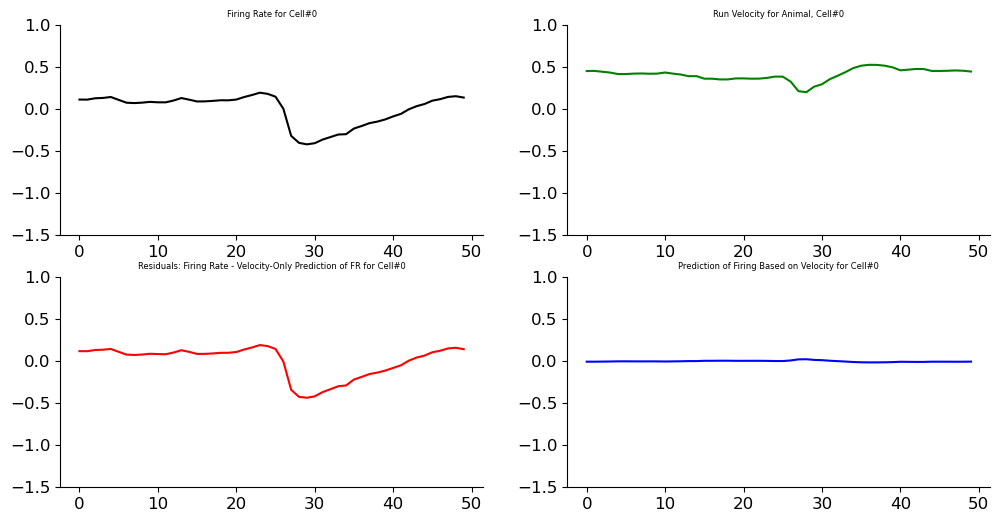

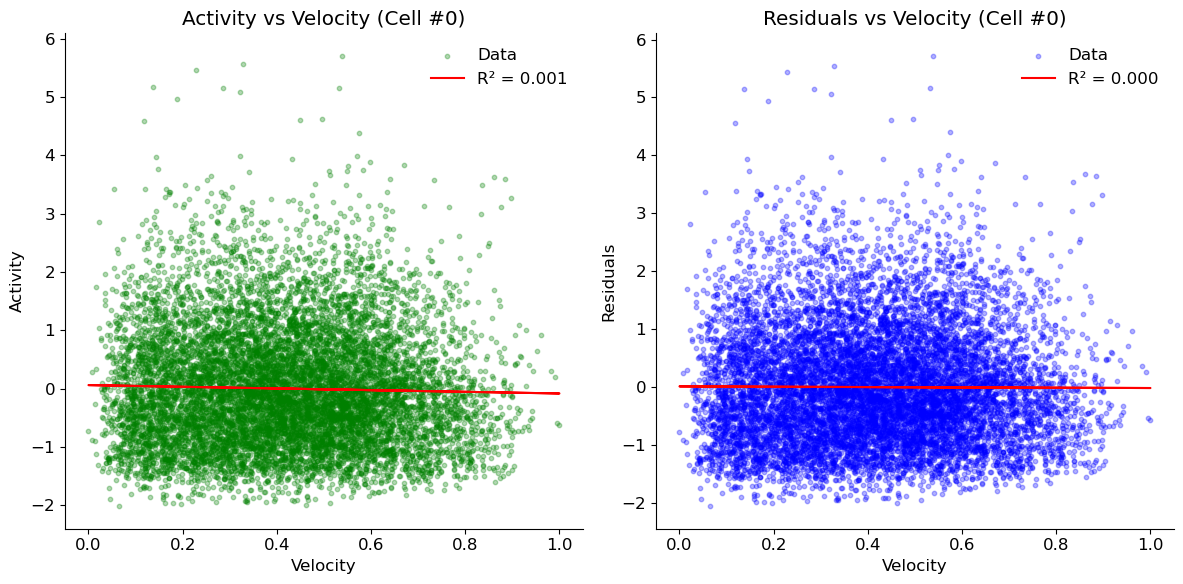

len(velocity_list) 75
velocity_list.shape[1] (50, 212)


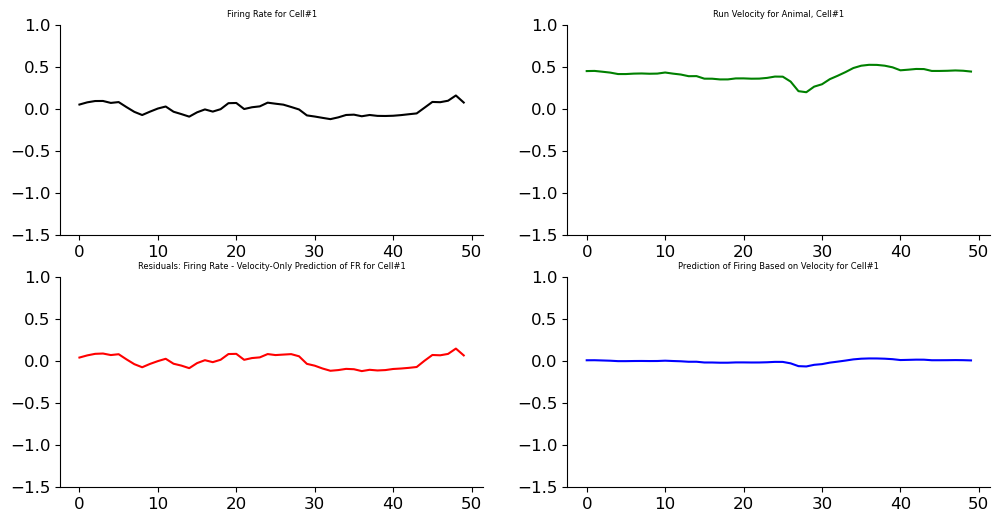

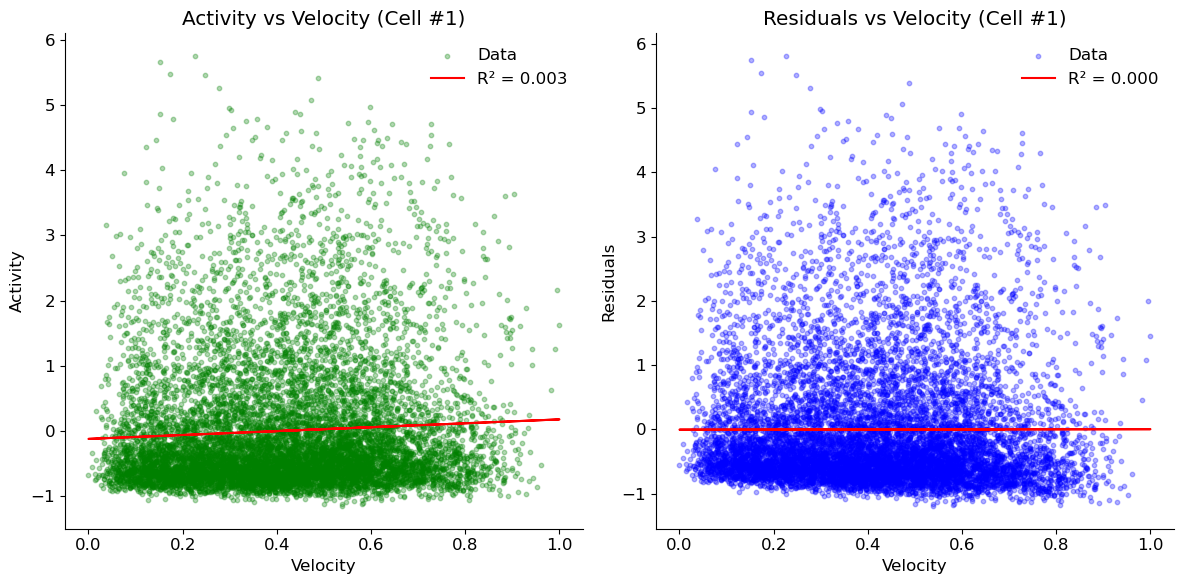

len(velocity_list) 75
velocity_list.shape[1] (50, 212)


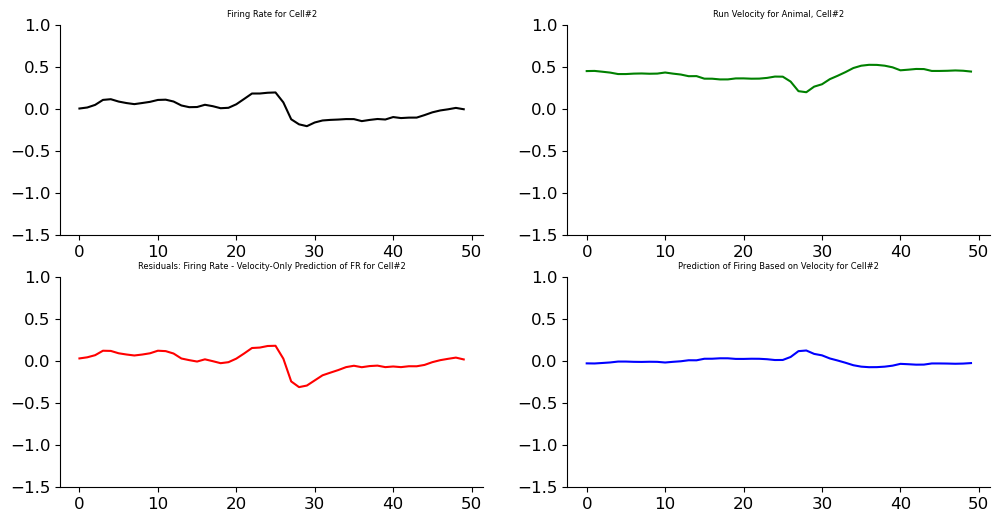

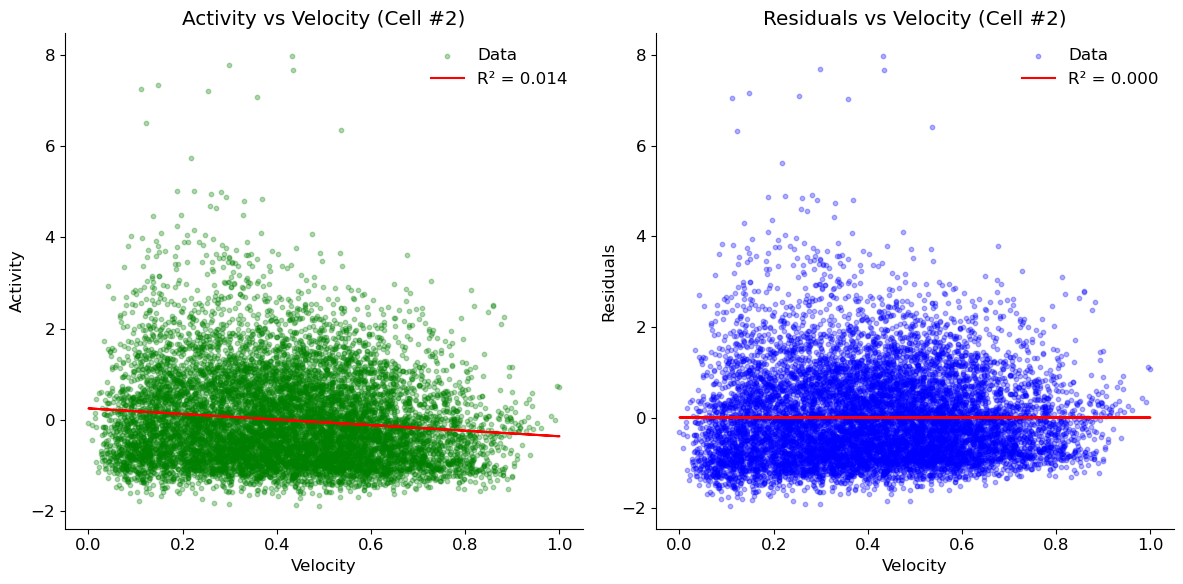

len(velocity_list) 75
velocity_list.shape[1] (50, 212)


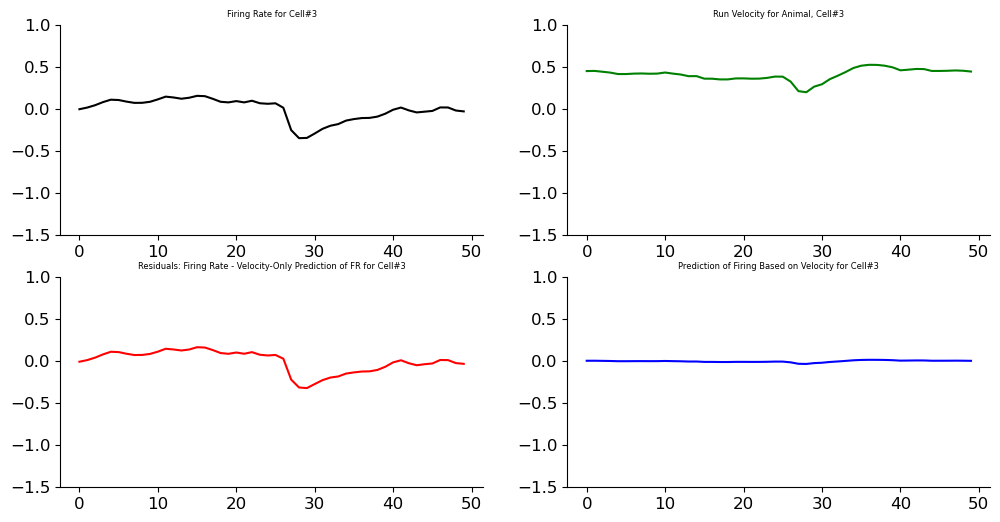

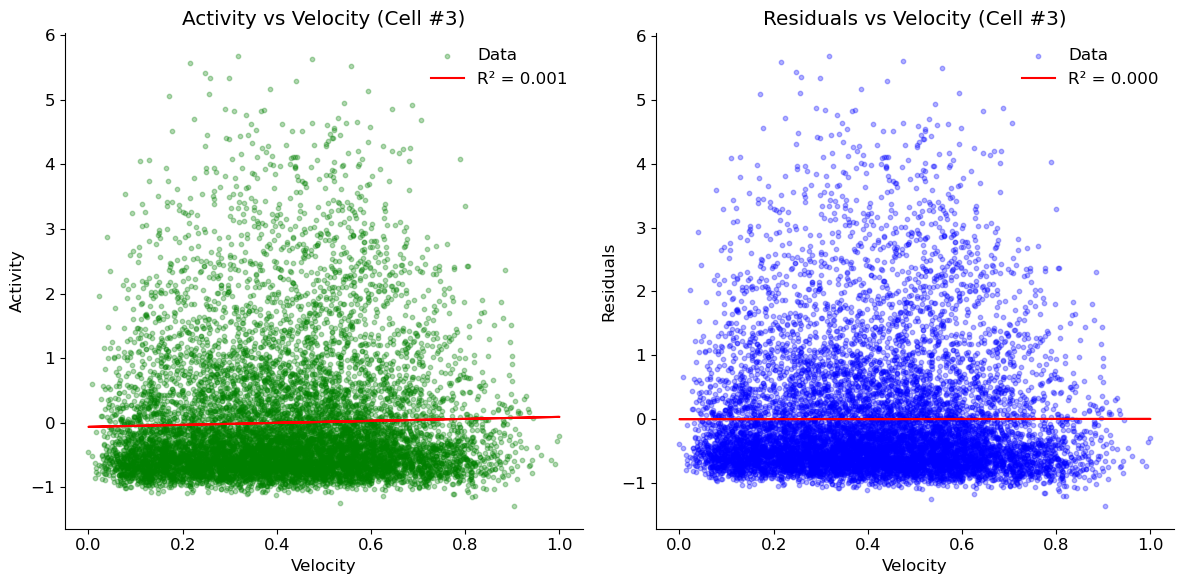

len(velocity_list) 75
velocity_list.shape[1] (50, 212)


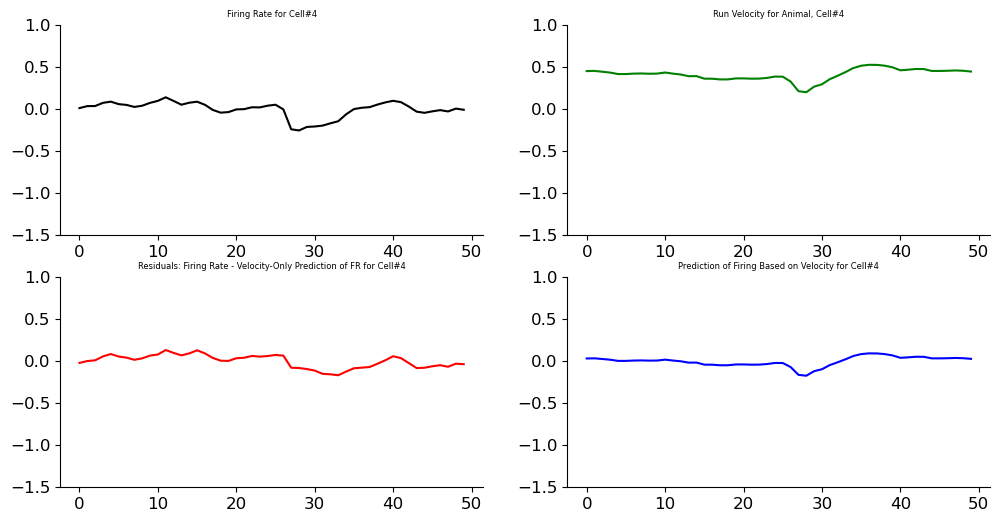

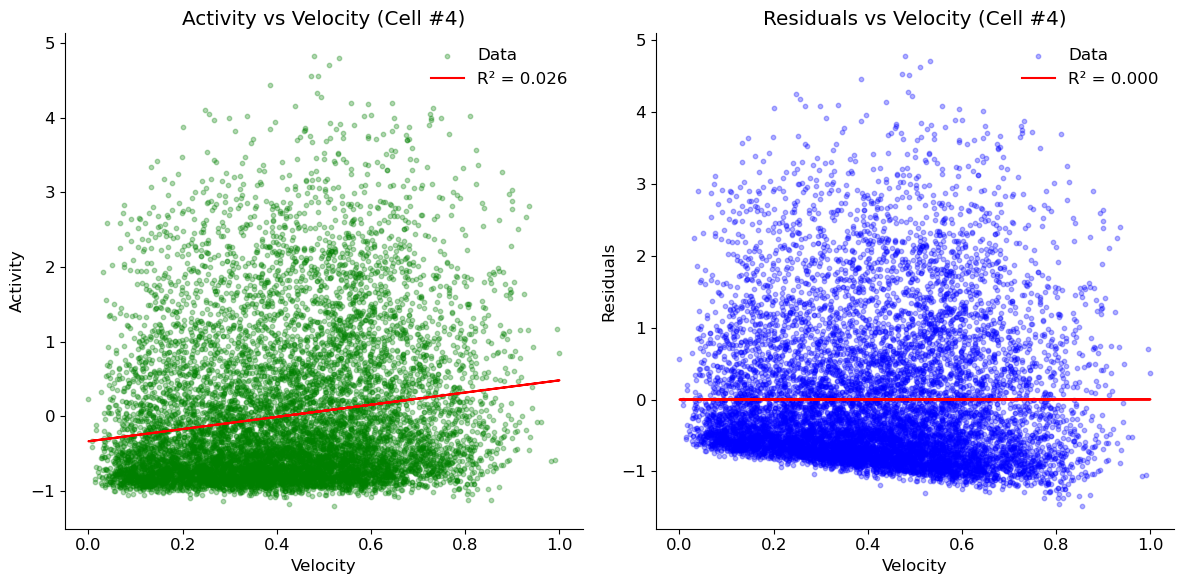

len(velocity_list) 75
velocity_list.shape[1] (50, 212)


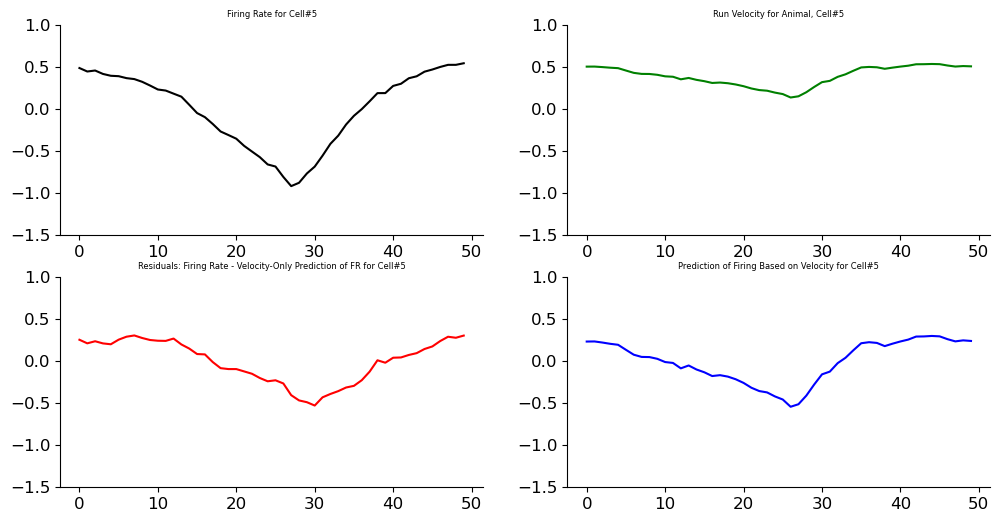

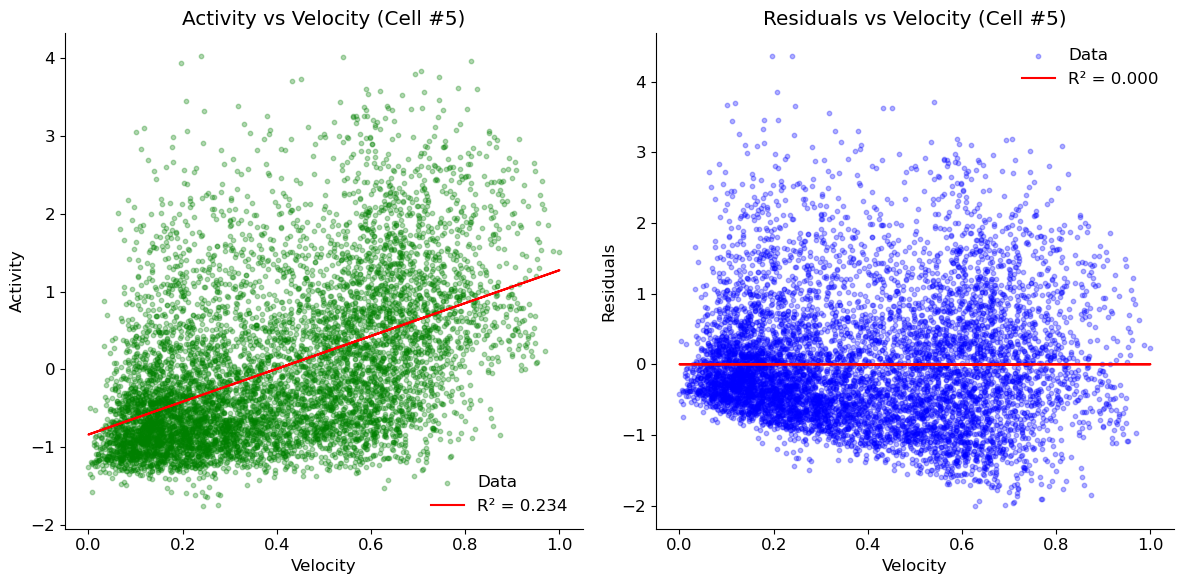

len(velocity_list) 75
velocity_list.shape[1] (50, 212)


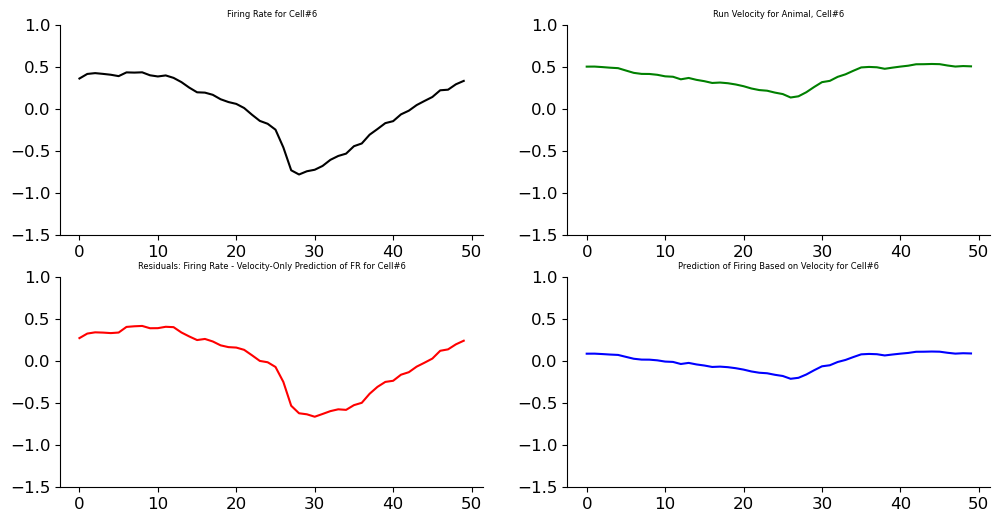

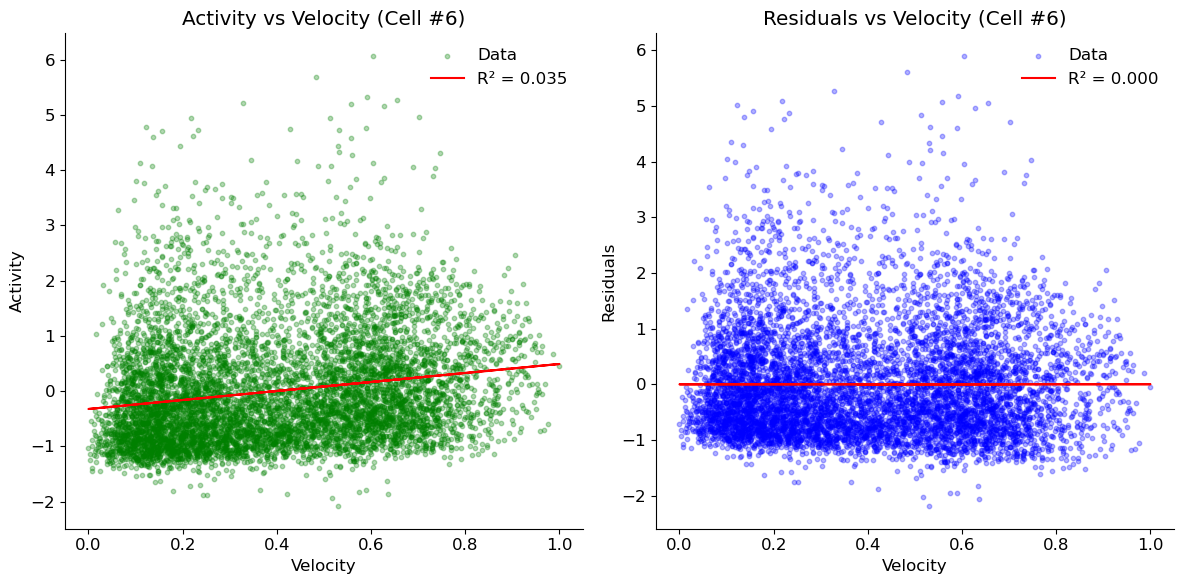

len(velocity_list) 75
velocity_list.shape[1] (50, 212)


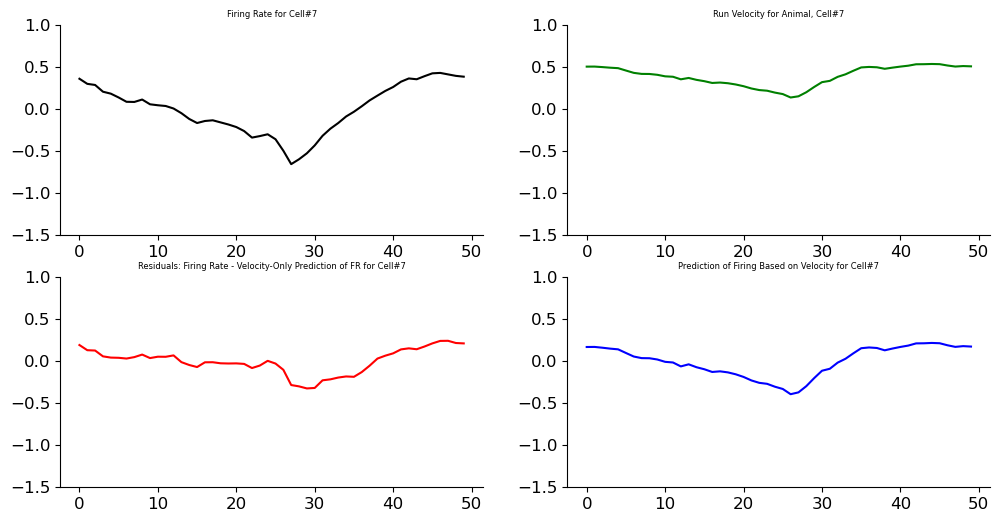

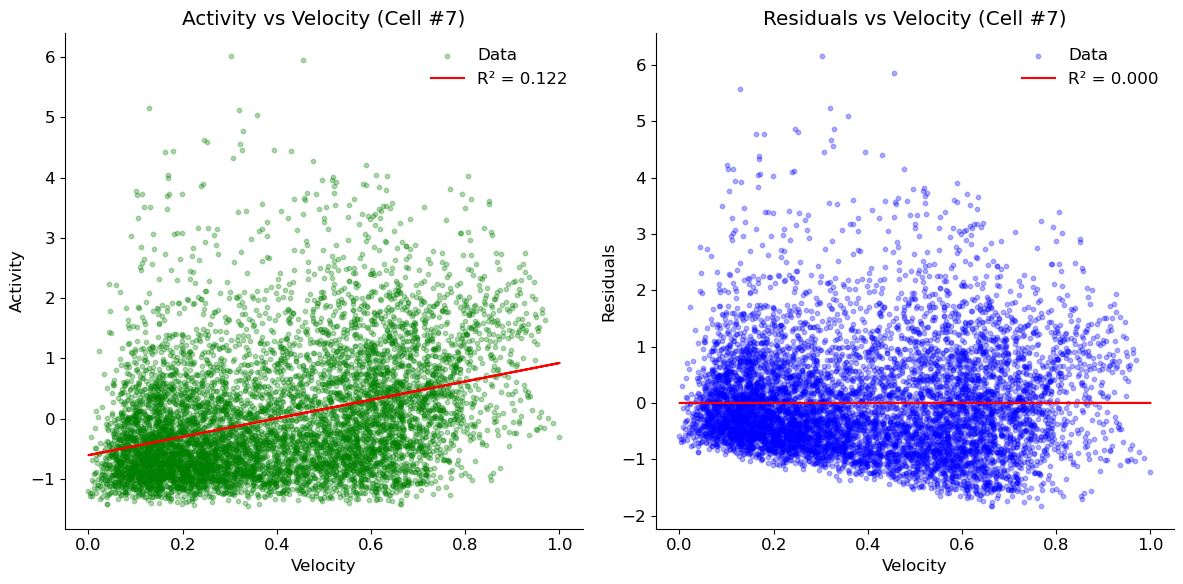

len(velocity_list) 75
velocity_list.shape[1] (50, 212)


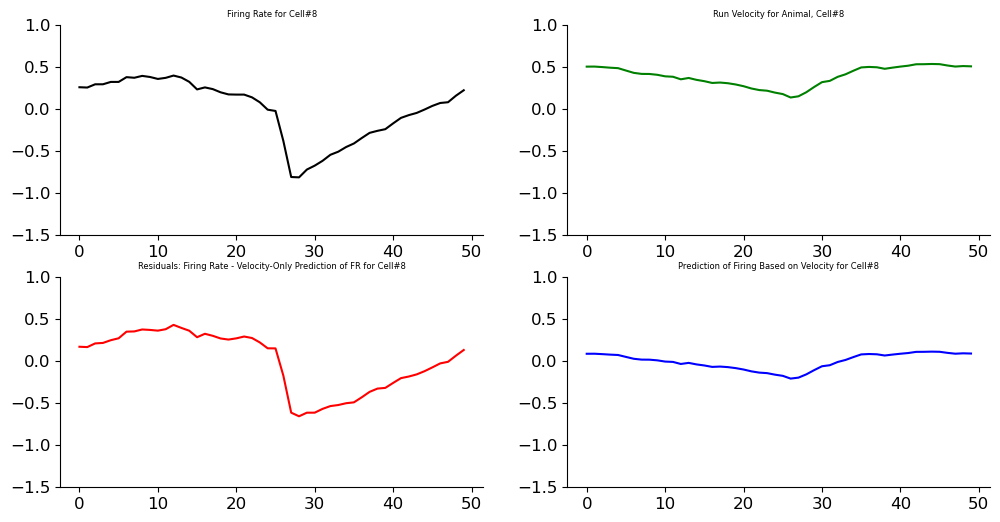

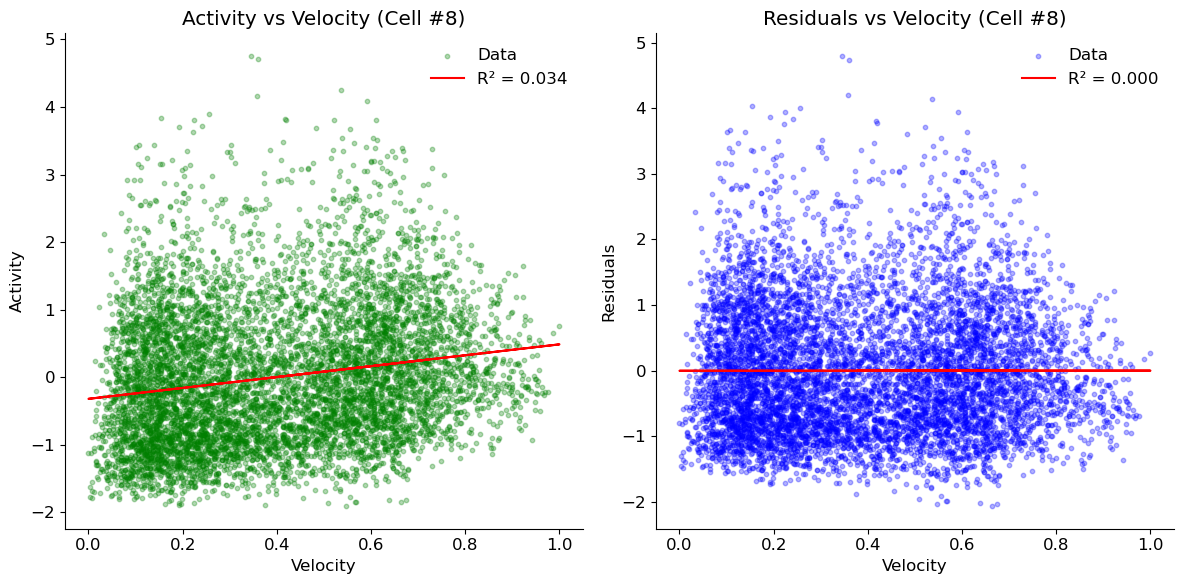

len(velocity_list) 75
velocity_list.shape[1] (50, 212)


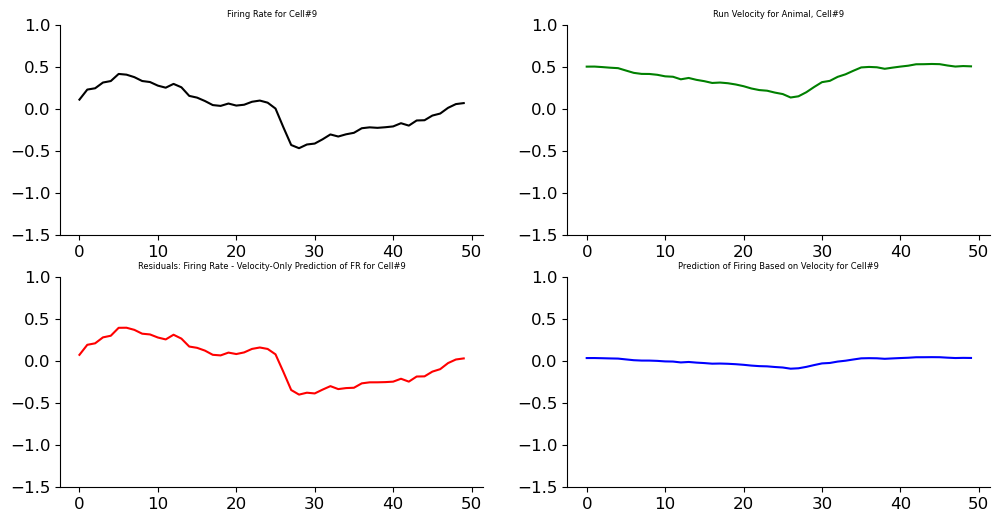

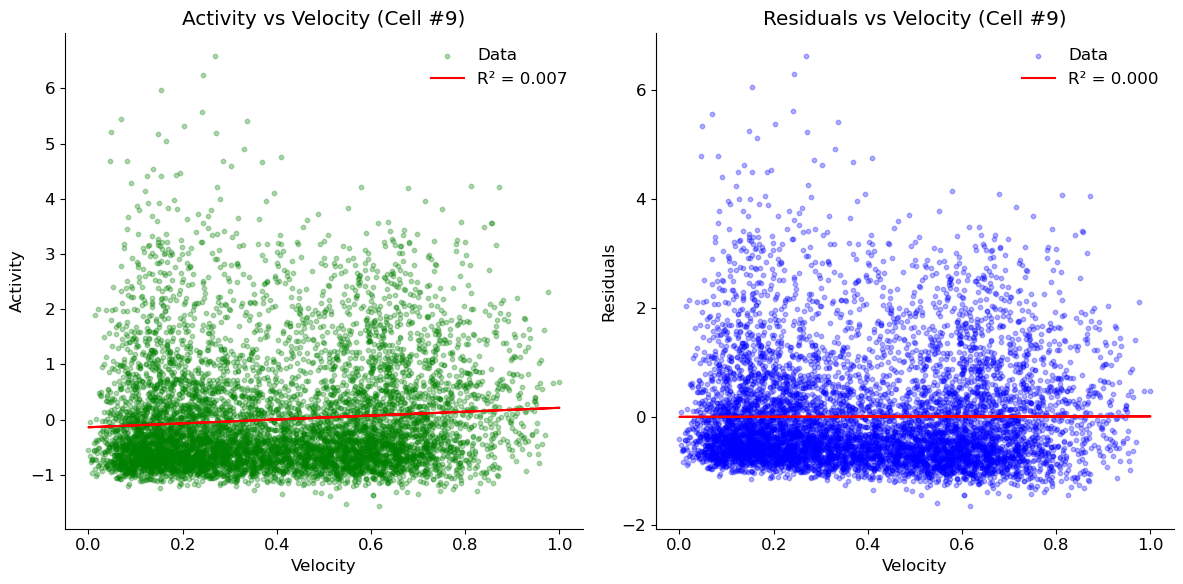

len(velocity_list) 75
velocity_list.shape[1] (50, 212)


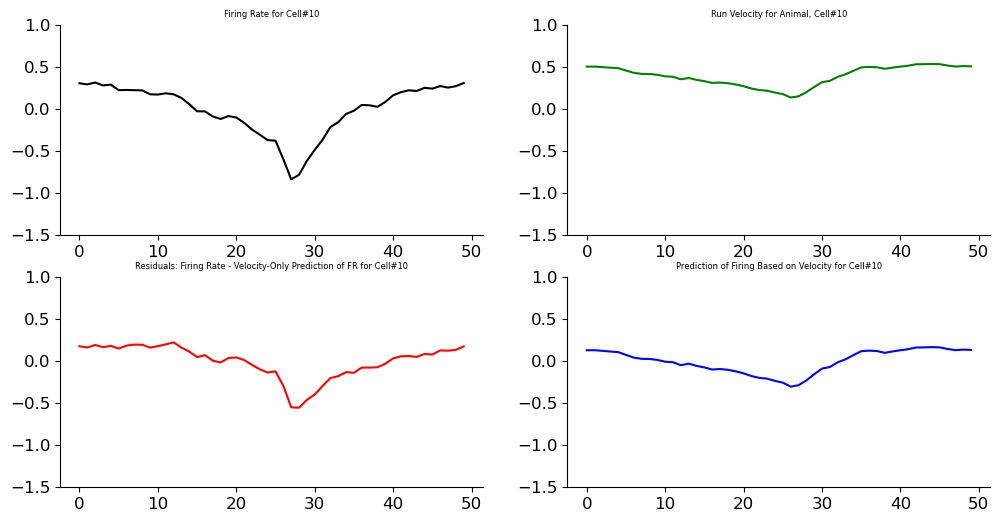

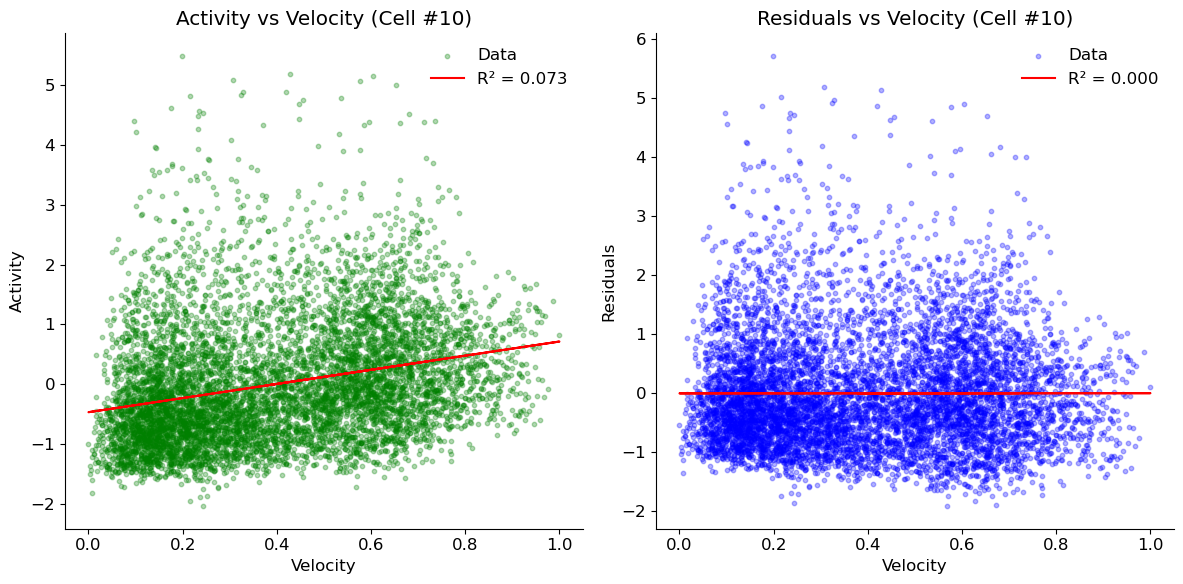

In [101]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

def plot_activity_residuals_correlation(reorganized_data, predicted_activity_list, neuron_activity_list, residuals_list, cell_number, variable_to_corelate=["Velocity"]):
    
    velocity_list = []
    for key, value in reorganized_data.items():
        for key2, value2 in value.items():
            velocity = value2["Velocity"]
            velocity_list.append(velocity) 
    
    trial_average_velocity_list = []
    for i in velocity_list:
        trial_average_velocity_list.append(np.mean(i, axis=1))

   
    trial_av_prediction_list = []
    for i in predicted_activity_list:
        trial_av_prediction_list.append(np.mean(i, axis=1))

        
    trial_av_neuron_activity_list = []
    for i in neuron_activity_list:
        trial_av_neuron_activity_list.append(np.mean(i, axis=1))
        
        
    
    trial_av_residuals_list = []
    for i in residuals_list:
        trial_av_residuals_list.append(np.mean(i, axis=1))
    
        

    fig, axs = plt.subplots(2,2, figsize=(12, 6))


    axs[0,0].plot(trial_av_neuron_activity_list[cell_number], color='k', label='neuron activity')
    axs[0,0].set_title(f"Firing Rate for Cell#{cell_number}", fontsize=6)
    axs[0,0].set_ylim(-1.5, 1)

    axs[0,1].plot(trial_average_velocity_list[cell_number], color='g')
    axs[0,1].set_title(f"Run Velocity for Animal, Cell#{cell_number}", fontsize=6)
    axs[0,1].set_ylim(-1.5, 1)
    
    
    
    axs[1,0].plot(trial_av_residuals_list[cell_number], color='r', label='residuals')
    axs[1,0].set_title(f"Residuals: Firing Rate - Velocity-Only Prediction of FR for Cell#{cell_number}", fontsize=6)
    axs[1,0].set_ylim(-1.5, 1)
    
    axs[1,1].plot(trial_av_prediction_list[cell_number], color='b', label='velocity prediction')
    axs[1,1].set_title(f"Prediction of Firing Based on Velocity for Cell#{cell_number}", fontsize=6)
    axs[1,1].set_ylim(-1.5, 1)
    
    
    r2_list_residuals = []
    r2_list_activity = []
    y_pred_activity_list = []
    y_pred_residuals_list = []
    
    for i in range(len(velocity_list)):
        
        velocity_flat = velocity_list[i].flatten()
        activity_flat = neuron_activity_list[i].flatten()
        residuals_flat = residuals_list[i].flatten()

        model_activity = LinearRegression()
        model_activity.fit(velocity_flat.reshape(-1, 1), activity_flat)
        y_pred_activity = model_activity.predict(velocity_flat.reshape(-1, 1))
        r2_activity = r2_score(activity_flat, y_pred_activity)
        r2_list_activity.append(r2_activity)
        y_pred_activity_list.append(y_pred_activity)

        model_residuals = LinearRegression()
        model_residuals.fit(velocity_flat.reshape(-1, 1), residuals_flat)
        y_pred_residuals = model_residuals.predict(velocity_flat.reshape(-1, 1))
        r2_residuals = r2_score(residuals_flat, y_pred_residuals)
        r2_list_residuals.append(r2_residuals)
        y_pred_residuals_list.append(y_pred_residuals)
        
        
    velocity_flat = velocity_list[cell_number].flatten()
    activity_flat = neuron_activity_list[cell_number].flatten()
    residuals_flat = residuals_list[cell_number].flatten()

    fig, axs = plt.subplots(1, 2, figsize=(12, 6))

    axs[0].scatter(velocity_flat, activity_flat, color="g", s=10, alpha=0.3, label="Data")
    axs[0].plot(
        velocity_flat, y_pred_activity_list[cell_number], color="r", label=f"R² = {r2_list_activity[cell_number]:.3f}"
    )
    axs[0].set_title(f"Activity vs Velocity (Cell #{cell_number})")
    axs[0].set_xlabel("Velocity")
    axs[0].set_ylabel("Activity")
    axs[0].legend()

    axs[1].scatter(velocity_flat, residuals_flat, color="b", s=10, alpha=0.3, label="Data")
    axs[1].plot(
        velocity_flat, y_pred_residuals_list[cell_number], color="r", label=f"R² = {r2_list_residuals[cell_number]:.3f}"
    )
    axs[1].set_title(f"Residuals vs Velocity (Cell #{cell_number})")
    axs[1].set_xlabel("Velocity")
    axs[1].set_ylabel("Residuals")
    axs[1].legend()

   
    plt.tight_layout()
    plt.show()

    
    return r2_list_residuals, r2_list_activity

cells = np.arange(0,11)
    
for i in cells:

    r2_list_residuals, r2_list_activity = plot_cell_velocity_neuron_activity_predicted_activity_off_velocity_and_residuals_gone(reorganized_data, predicted_activity_list, neuron_activity_list, residuals_list, i)
    
    

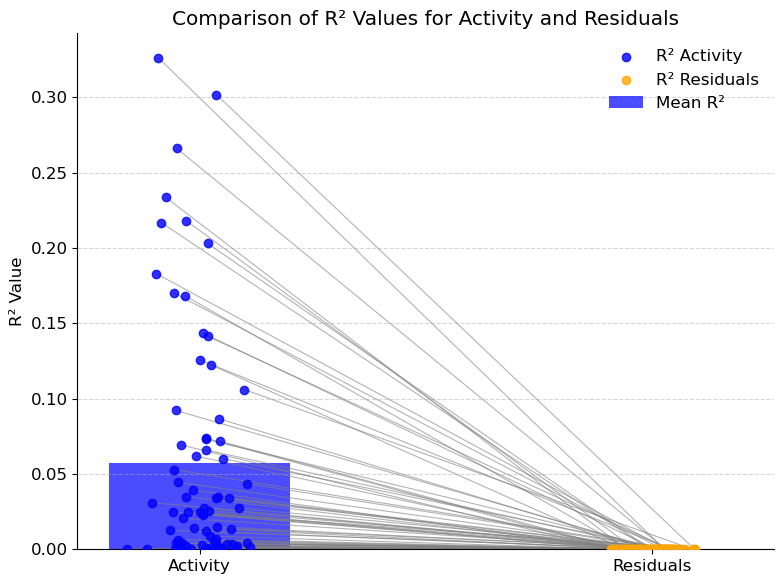

In [102]:
def plot_r2_difference_vs_velocity(r2_list_activity, r2_list_residuals):
    
    r2_list_activity = np.array(r2_list_activity)
    r2_list_residuals = np.array(r2_list_residuals)
    mean_activity = np.mean(r2_list_activity)
    mean_residuals = np.mean(r2_list_residuals)

    positions = [0, 1]

    plt.figure(figsize=(8, 6))

    plt.bar(positions, [mean_activity, mean_residuals], color=['blue', 'orange'], alpha=0.7, width=0.4, label='Mean R²')

    x_jitter_activity = np.random.normal(positions[0], 0.05, size=len(r2_list_activity))  
    x_jitter_residuals = np.random.normal(positions[1], 0.05, size=len(r2_list_residuals)) 

    plt.scatter(x_jitter_activity, r2_list_activity, color='blue', alpha=0.8, label='R² Activity', zorder=3)
    plt.scatter(x_jitter_residuals, r2_list_residuals, color='orange', alpha=0.8, label='R² Residuals', zorder=3)

    for i in range(len(r2_list_activity)):
        plt.plot([x_jitter_activity[i], x_jitter_residuals[i]],
                 [r2_list_activity[i], r2_list_residuals[i]],
                 color='gray', alpha=0.6, linewidth=0.8)


    plt.xticks(positions, ['Activity', 'Residuals'])
    plt.ylabel("R² Value")
    plt.title("Comparison of R² Values for Activity and Residuals")
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.5)


    plt.tight_layout()
    plt.show()

plot_r2_difference_vs_velocity(r2_list_activity, r2_list_residuals)

In [ ]:
##### running GLM on only velocity

In [ ]:
reorganized_data = preprocess_data(filepath, normalize=True)

filtered_data_dict = subset_variables_from_data(reorganized_data, variables_to_keep=["Poaition"])

GLM_params, predicted_activity_dict = fit_GLM(filtered_data_dict, quintile=None, regression='ridge', renormalize=True, alphas=None):

In [ ]:
subset_variables_from_data(reorganized_data, variables_to_keep=["Velocity"])

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

def plot_activity_residuals_correlation(reorganized_data, predicted_activity_list, neuron_activity_list, residuals_list, cell_number, variable_to_corelate="Position"):
    
    variable_list = []
    for key, value in reorganized_data.items():
        for key2, value2 in value.items():
            velocity = value2[variable_to_corelate]
            variable_list.append(velocity) 
            
    print(f"len(variable_list) {len(variable_list)}")
    print(f"variable_list.shape[1] {variable_list[1].shape}")
    
    trial_average_variable_list = []
    for i in variable_list:
        trial_average_variable_list.append(np.mean(i, axis=1))

   
    trial_av_prediction_list = []
    for i in predicted_activity_list:
        trial_av_prediction_list.append(np.mean(i, axis=1))

        
    trial_av_neuron_activity_list = []
    for i in neuron_activity_list:
        trial_av_neuron_activity_list.append(np.mean(i, axis=1))
        
        
    
    trial_av_residuals_list = []
    for i in residuals_list:
        trial_av_residuals_list.append(np.mean(i, axis=1))
    
        

    fig, axs = plt.subplots(2,2, figsize=(12, 6))


    axs[0,0].plot(trial_av_neuron_activity_list[cell_number], color='k', label='neuron activity')
    axs[0,0].set_title(f"Firing Rate for Cell#{cell_number}", fontsize=6)
    axs[0,0].set_ylim(-1.5, 1)

    axs[0,1].plot(trial_average_variable_list[cell_number], color='g')
    axs[0,1].set_title(f"Run Velocity for Animal, Cell#{cell_number}", fontsize=6)
    axs[0,1].set_ylim(-1.5, 1)
    
    
    
    axs[1,0].plot(trial_av_residuals_list[cell_number], color='r', label='residuals')
    axs[1,0].set_title(f"Residuals: Firing Rate - Velocity-Only Prediction of FR for Cell#{cell_number}", fontsize=6)
    axs[1,0].set_ylim(-1.5, 1)
    
    axs[1,1].plot(trial_av_prediction_list[cell_number], color='b', label='velocity prediction')
    axs[1,1].set_title(f"Prediction of Firing Based on Velocity for Cell#{cell_number}", fontsize=6)
    axs[1,1].set_ylim(-1.5, 1)
    
    
    r2_list_residuals = []
    r2_list_activity = []
    y_pred_activity_list = []
    y_pred_residuals_list = []
    
    for i in range(len(variable_list)):
        
        velocity_flat = variable_list[i].flatten()
        activity_flat = neuron_activity_list[i].flatten()
        residuals_flat = residuals_list[i].flatten()

        model_activity = LinearRegression()
        model_activity.fit(velocity_flat.reshape(-1, 1), activity_flat)
        y_pred_activity = model_activity.predict(velocity_flat.reshape(-1, 1))
        r2_activity = r2_score(activity_flat, y_pred_activity)
        r2_list_activity.append(r2_activity)
        y_pred_activity_list.append(y_pred_activity)

        model_residuals = LinearRegression()
        model_residuals.fit(velocity_flat.reshape(-1, 1), residuals_flat)
        y_pred_residuals = model_residuals.predict(velocity_flat.reshape(-1, 1))
        r2_residuals = r2_score(residuals_flat, y_pred_residuals)
        r2_list_residuals.append(r2_residuals)
        y_pred_residuals_list.append(y_pred_residuals)
        
        
    velocity_flat = variable_list[cell_number].flatten()
    activity_flat = neuron_activity_list[cell_number].flatten()
    residuals_flat = residuals_list[cell_number].flatten()

    fig, axs = plt.subplots(1, 2, figsize=(12, 6))

    axs[0].scatter(velocity_flat, activity_flat, color="g", s=10, alpha=0.3, label="Data")
    axs[0].plot(
        velocity_flat, y_pred_activity_list[cell_number], color="r", label=f"R² = {r2_list_activity[cell_number]:.3f}"
    )
    axs[0].set_title(f"Activity vs Velocity (Cell #{cell_number})")
    axs[0].set_xlabel("Velocity")
    axs[0].set_ylabel("Activity")
    axs[0].legend()

    axs[1].scatter(velocity_flat, residuals_flat, color="b", s=10, alpha=0.3, label="Data")
    axs[1].plot(
        velocity_flat, y_pred_residuals_list[cell_number], color="r", label=f"R² = {r2_list_residuals[cell_number]:.3f}"
    )
    axs[1].set_title(f"Residuals vs Velocity (Cell #{cell_number})")
    axs[1].set_xlabel("Velocity")
    axs[1].set_ylabel("Residuals")
    axs[1].legend()

   
    plt.tight_layout()
    plt.show()

    
    return r2_list_residuals, r2_list_activity

cells = np.arange(0,11)
    
for i in cells:

    r2_list_residuals, r2_list_activity = plot_cell_velocity_neuron_activity_predicted_activity_off_velocity_and_residuals_gone(reorganized_data, predicted_activity_list, neuron_activity_list, residuals_list, i)
    

In [130]:

import numpy as np
import mat73  # Ensure you have this library installed

data_dict = mat73.loadmat(filepath_SST)

num_spatial_bins = 10
position_matrix = np.zeros((50, num_spatial_bins))
bin_size = 50 // num_spatial_bins
for i in range(num_spatial_bins):
    position_matrix[i * bin_size:(i + 1) * bin_size, i] = 1

reorganized_data = {}
for animal_idx, (delta_f, velocity, lick_rate, reward_loc) in enumerate(
        zip(data_dict['animal']['ShiftR'], data_dict['animal']['ShiftRunning'], data_dict['animal']['ShiftLrate'],
            data_dict['animal']['ShiftV'])):

    animal_key = f'animal_{animal_idx + 1}'
    reorganized_data[animal_key] = {}
    
    for neuron_idx in range(delta_f.shape[2]):
        activity_data = delta_f[:, :, neuron_idx]
        if np.all(np.isnan(activity_data)) or np.all(activity_data == 0):
            continue

        # Count the number of NaNs in the activity data
        num_nans = np.isnan(activity_data).sum()
        
        # Print the shape and number of NaNs
        print(f"Shape of activity_data: {activity_data.shape}, Number of NaNs: {num_nans}")

        neuron_dict = {
            "Activity": activity_data,
            "Licks": lick_rate,
            "Reward_loc": reward_loc,
            "Velocity": velocity,
            "Position": np.repeat(position_matrix[:, :, np.newaxis], delta_f.shape[1], axis=2)
        }

    

Shape of activity_data: (50, 213), Number of NaNs: 47
Shape of activity_data: (50, 213), Number of NaNs: 47
Shape of activity_data: (50, 213), Number of NaNs: 47
Shape of activity_data: (50, 213), Number of NaNs: 47
Shape of activity_data: (50, 213), Number of NaNs: 47
Shape of activity_data: (50, 159), Number of NaNs: 277
Shape of activity_data: (50, 159), Number of NaNs: 277
Shape of activity_data: (50, 159), Number of NaNs: 277
Shape of activity_data: (50, 159), Number of NaNs: 277
Shape of activity_data: (50, 159), Number of NaNs: 277
Shape of activity_data: (50, 159), Number of NaNs: 277
Shape of activity_data: (50, 159), Number of NaNs: 277
Shape of activity_data: (50, 159), Number of NaNs: 277
Shape of activity_data: (50, 159), Number of NaNs: 277
Shape of activity_data: (50, 159), Number of NaNs: 277
Shape of activity_data: (50, 159), Number of NaNs: 277
Shape of activity_data: (50, 159), Number of NaNs: 277
Shape of activity_data: (50, 159), Number of NaNs: 277
Shape of activi